<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/20_regularization/20_1_Practical_Training/20_1_2_BatchNorm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regularization: Part 2
## Batch Normalization

---

## What This Notebook Is About

In notebook 20_1_1 you met your first regularization tool, **dropout**, and finally got a real explanation of `model.train()` and `model.eval()`. This notebook introduces a second technique that shows up in almost every modern network: **batch normalization**.

The two tools solve different problems. Dropout fights *overfitting* — a model that memorizes its training set. Batch normalization fights *unstable training* — the way the signal flowing through a deep network can shrink toward nothing or blow up as it passes from layer to layer, making the network slow and finicky to train. The fix is simple to state: normalize each layer's activations to roughly zero mean and unit variance, *inside the network*, on every forward pass.

There is a nice payoff at the end. Batch normalization is the second layer (after dropout) whose behavior depends on the train/eval mode switch — but for a completely different reason. Understanding both reasons is the point of this module.

**What you will learn:**
1. Why activation magnitudes drift as a network gets deeper, and why that hurts training
2. How to place `nn.BatchNorm1d` correctly: `Linear → BatchNorm → ReLU`
3. Why BatchNorm needs `model.train()` / `model.eval()` — the *running statistics* story
4. How BatchNorm and dropout stack into the standard block `Linear → BatchNorm → ReLU → Dropout`
5. What BatchNorm actually buys you: stable training, even at large learning rates

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import seaborn as sns
sns.set_theme(style='whitegrid')
torch.manual_seed(42)

# Load the Wisconsin Breast Cancer dataset (same as 19_1_2 and 20_1_1)
data  = load_breast_cancer()
X_raw = data.data.astype(np.float32)    # 569 samples x 30 features
y_raw = data.target.astype(np.float32)  # 0=malignant, 1=benign

# Three-way split: 60% train / 20% val / 20% test (same recipe as 20_1_1).
X_tmp, X_test_np, y_tmp, y_test_np = train_test_split(
    X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=42
)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=42  # 0.25 x 0.80 = 0.20
)

# Standardize: fit on training data only, then transform all three splits
scaler     = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_val_np   = scaler.transform(X_val_np)
X_test_np  = scaler.transform(X_test_np)

# Convert to tensors; targets are shape (n, 1) to match the network's output
X_train = torch.tensor(X_train_np)
X_val   = torch.tensor(X_val_np)
X_test  = torch.tensor(X_test_np)
y_train = torch.tensor(y_train_np).unsqueeze(1)
y_val   = torch.tensor(y_val_np).unsqueeze(1)
y_test  = torch.tensor(y_test_np).unsqueeze(1)

BATCH_SIZE   = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)

print(f'Train : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print(f'Features: {X_train.shape[1]}')

Train : 341 samples
Val   : 114 samples
Test  : 114 samples
Features: 30


In [2]:
def train_and_track(model, optimizer, n_epochs):
    """Train a binary classifier, returning per-epoch train and validation loss.

    This is the same canonical loop from 19_1_2 and 20_1_1: each epoch we put the
    model in training mode, run the mini-batches (zero_grad -> forward -> loss ->
    backward -> step), then switch to eval mode to measure validation loss."""
    criterion = nn.BCELoss()
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        # --- training phase ---
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        # --- validation phase (no gradient updates) ---
        model.eval()
        with torch.no_grad():
            val_losses.append(criterion(model(X_val), y_val).item())

    return train_losses, val_losses

---

## Section 1: The Problem BatchNorm Solves

Standardizing the *inputs* with `StandardScaler` (which we always do) only fixes the very first layer. Once the signal passes through a few `Linear → ReLU` blocks, there is no guarantee it stays well-behaved — each layer rescales and reshapes whatever it receives, and small effects compound with depth. The signal can steadily **shrink toward zero** (the gradients that depend on it vanish, and learning stalls) or **blow up** (training becomes unstable). This drift in the distribution of each layer's inputs as the parameters change is sometimes called *internal covariate shift*.

Let's make it visible. We build a deep stack of `Linear → ReLU` blocks with no normalization, push one mini-batch through it, and measure the standard deviation of the activations after each layer. Watch what happens to the magnitude as we go deeper.

In [3]:
class DeepNet(nn.Module):
    """A deep stack of Linear -> (optional BatchNorm) -> ReLU blocks.

    forward(record=True) also returns the std of the activations after each block,
    so we can watch how the signal magnitude changes from layer to layer."""
    def __init__(self, use_bn=False, width=128, depth=8):
        super().__init__()
        self.blocks = nn.ModuleList()
        in_dim = 30
        for _ in range(depth):
            layers = [nn.Linear(in_dim, width)]
            if use_bn:
                layers.append(nn.BatchNorm1d(width))
            layers.append(nn.ReLU())
            self.blocks.append(nn.Sequential(*layers))
            in_dim = width

    def forward(self, x, record=False):
        stds = []
        for block in self.blocks:
            x = block(x)
            stds.append(x.std().item())
        return (x, stds) if record else x


batch = X_train[:64]   # one mini-batch of standardized inputs

torch.manual_seed(0)
plain_deep = DeepNet(use_bn=False)
plain_deep.train()
_, plain_stds = plain_deep(batch, record=True)

print('Activation std after each layer (NO normalization):')
for i, s in enumerate(plain_stds, 1):
    print(f'  layer {i}: {s:.4f}')

Activation std after each layer (NO normalization):
  layer 1: 0.3379
  layer 2: 0.1501
  layer 3: 0.0670
  layer 4: 0.0415
  layer 5: 0.0351
  layer 6: 0.0308
  layer 7: 0.0290
  layer 8: 0.0296


The standard deviation **decays layer after layer** — the signal is quietly fading toward zero as it moves deeper into the network. (With a different initialization it can do the opposite and explode; either way, the magnitude is at the mercy of depth.) A near-zero activation carries almost no information forward and produces almost no gradient backward, so the early layers of a deep network like this learn painfully slowly. We standardized the inputs, but that guarantee was gone after the very first layer.

---

## Section 2: `nn.BatchNorm1d` in Practice

Batch normalization restores the guarantee at *every* layer. For a fully connected layer, `nn.BatchNorm1d(num_features)` takes the activations in a mini-batch and, for each feature, subtracts the batch mean and divides by the batch standard deviation — forcing roughly zero mean and unit variance. It then applies two **learned** parameters, a scale (`gamma`) and a shift (`beta`), so the network can undo the normalization if that turns out to be useful. Those learned parameters are why BatchNorm is a real layer with weights, not just a fixed transformation.

**Placement matters.** The standard order is `Linear → BatchNorm → ReLU`: normalize the linear layer's output *before* the activation squashes it. (You will occasionally see `Linear → ReLU → BatchNorm` in the wild; there is a long-running debate, but `Linear → BatchNorm → ReLU` is the safe default — use it.)

First, BatchNorm on a single batch of badly-scaled data, to see the normalization happen:

In [4]:
torch.manual_seed(0)
bn = nn.BatchNorm1d(5)
bn.train()

x   = torch.randn(64, 5) * 5 + 10   # 5 features, deliberately far from mean 0 / std 1
out = bn(x)

print('Per-feature mean BEFORE BatchNorm:', x.mean(0).detach().numpy().round(2))
print('Per-feature std  BEFORE BatchNorm:', x.std(0).detach().numpy().round(2))
print()
print('Per-feature mean AFTER  BatchNorm:', out.mean(0).detach().numpy().round(2))
print('Per-feature std  AFTER  BatchNorm:', out.std(0).detach().numpy().round(2))

Per-feature mean BEFORE BatchNorm: [ 9.93  9.42 10.02  9.74 11.  ]
Per-feature std  BEFORE BatchNorm: [4.7  4.77 4.41 3.91 5.21]

Per-feature mean AFTER  BatchNorm: [-0.  0. -0.  0.  0.]
Per-feature std  AFTER  BatchNorm: [1.01 1.01 1.01 1.01 1.01]


The output of every feature now sits at about mean 0 and std 1, regardless of how the inputs were scaled. Now put a `BatchNorm1d` into each block of the deep network from Section 1 and re-measure the per-layer activation std. Compare it against the un-normalized run:

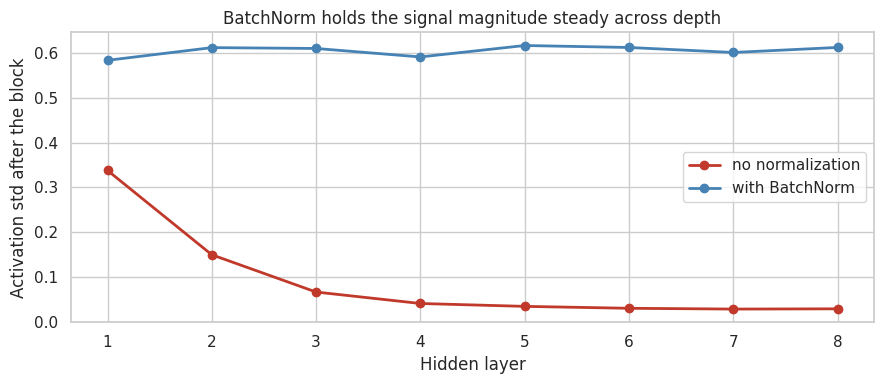

Activation std, layer 1 -> layer 8:
  no normalization: 0.3379  ...  0.0296
  with BatchNorm  : 0.5833  ...  0.6120


In [5]:
torch.manual_seed(0)
bn_deep = DeepNet(use_bn=True)
bn_deep.train()
_, bn_stds = bn_deep(batch, record=True)

fig, ax = plt.subplots(figsize=(9, 4))
layers = range(1, len(plain_stds) + 1)
ax.plot(layers, plain_stds, 'o-', color='#C0392B',   lw=2, label='no normalization')
ax.plot(layers, bn_stds,    'o-', color='steelblue', lw=2, label='with BatchNorm')
ax.set_xlabel('Hidden layer')
ax.set_ylabel('Activation std after the block')
ax.set_title('BatchNorm holds the signal magnitude steady across depth')
ax.legend()
plt.tight_layout()
plt.show()

print('Activation std, layer 1 -> layer 8:')
print(f'  no normalization: {plain_stds[0]:.4f}  ...  {plain_stds[-1]:.4f}')
print(f'  with BatchNorm  : {bn_stds[0]:.4f}  ...  {bn_stds[-1]:.4f}')

The red line slides toward zero; the blue line stays flat and healthy from the first layer to the last. By resetting the scale at every block, BatchNorm keeps a usable signal flowing all the way through the network — which is exactly what lets deep networks train quickly and tolerate larger learning rates.

---

## Section 3: Why BatchNorm Needs `model.train()` and `model.eval()`

Like dropout, BatchNorm behaves differently in the two modes — but the reason is different, and it is worth understanding precisely.

The problem BatchNorm has to solve: at training time it normalizes using the **current mini-batch's** mean and std. But at prediction time you might be classifying a *single* sample — there is no batch to compute statistics from, and even if there were, you do not want a prediction to depend on which other samples happened to be batched alongside it.

The solution: during training, BatchNorm keeps a slow running average of the mean and variance it sees — the `running_mean` and `running_var` buffers. These accumulate over training and become the network's best estimate of the population statistics.

- **`model.train()`** — normalize using the current batch's statistics, *and* update the running averages.
- **`model.eval()`** — stop updating, and normalize every input using the frozen running statistics instead. Predictions become deterministic and independent of the batch.

First, watch the running statistics accumulate during training-mode forward passes:

In [6]:
torch.manual_seed(0)
bn = nn.BatchNorm1d(30)

print('Fresh running stats (initialized to mean 0, var 1, before seeing any data):')
print(f'  running_mean[:3] = {bn.running_mean[:3].numpy().round(3)}')
print(f'  running_var[:3]  = {bn.running_var[:3].numpy().round(3)}')

# Feed 50 training-mode batches; the running averages move toward the real data
bn.train()
for _ in range(50):
    idx = torch.randint(0, len(X_train), (32,))
    bn(X_train[idx])

print('\nAfter 50 training-mode batches (running stats have moved toward the data):')
print(f'  running_mean[:3] = {bn.running_mean[:3].numpy().round(3)}')
print(f'  running_var[:3]  = {bn.running_var[:3].numpy().round(3)}')

Fresh running stats (initialized to mean 0, var 1, before seeing any data):
  running_mean[:3] = [0. 0. 0.]
  running_var[:3]  = [1. 1. 1.]

After 50 training-mode batches (running stats have moved toward the data):
  running_mean[:3] = [-0.01  -0.092 -0.014]
  running_var[:3]  = [0.991 0.972 0.993]


Now the bug this prevents. Suppose you evaluate while accidentally still in `train()` mode. Every forward pass keeps *updating* the running statistics — so evaluating the model literally changes the model, and you get a slightly different answer each time. Switching to `eval()` freezes everything:

In [7]:
val_batch = X_val[:16]

# WRONG: evaluating in train() mode keeps mutating the running statistics
bn.train()
print('Eval done in TRAIN mode  -> running_mean[0] drifts on every call:')
for i in range(3):
    bn(val_batch)
    print(f'  call {i + 1}: running_mean[0] = {bn.running_mean[0].item():.4f}')

# RIGHT: eval() freezes the running statistics
bn.eval()
print('\nEval done in EVAL mode   -> running_mean[0] is frozen:')
for i in range(3):
    bn(val_batch)
    print(f'  call {i + 1}: running_mean[0] = {bn.running_mean[0].item():.4f}')

Eval done in TRAIN mode  -> running_mean[0] drifts on every call:
  call 1: running_mean[0] = -0.0081
  call 2: running_mean[0] = -0.0061
  call 3: running_mean[0] = -0.0043

Eval done in EVAL mode   -> running_mean[0] is frozen:
  call 1: running_mean[0] = -0.0043
  call 2: running_mean[0] = -0.0043
  call 3: running_mean[0] = -0.0043


In train mode the statistic keeps moving; in eval mode it is rock steady. This is the BatchNorm half of the `model.train()` / `model.eval()` rule:

- **Dropout** (20_1_1): the mode switch turns the random zeroing *on* (train) or *off* (eval).
- **BatchNorm** (here): the mode switch decides whether to use *batch* statistics and keep updating the running averages (train), or use the *frozen running* statistics (eval).

Both layers are silently wrong if you forget the switch, and neither one raises an error — which is exactly why `model.train()` and `model.eval()` are habits worth burning in.

---

## Section 4: BatchNorm and Dropout Together

BatchNorm and dropout are routinely used in the same network, and there is a conventional order for stacking all four pieces:

```
Linear → BatchNorm → ReLU → Dropout
```

The logic: BatchNorm normalizes the linear output *before* the activation; dropout regularizes *after* the activation. Here is the combined block written out — this is the template you will reuse in the full pipeline in 20_1_5:

In [8]:
class BlockNet(nn.Module):
    """Standard regularized block: Linear -> BatchNorm -> ReLU -> Dropout."""
    def __init__(self, dropout_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(256, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


print(BlockNet())

BlockNet(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


---

## Section 5: What BatchNorm Buys You

BatchNorm has a reputation for two things: *faster convergence* and *more stable* training. It is worth being honest about when each one actually shows up. On a small, easy dataset like this, trained with Adam — whose adaptive per-parameter steps already compensate for badly-scaled gradients — a plain network converges just fine, and BatchNorm does **not** visibly speed it up. (The faster-convergence reputation comes from deep networks and from plain SGD, where the vanishing-signal problem from Section 1 actually bites.) Where BatchNorm earns its keep *here* is **stability**: it lets you push the learning rate far higher than a plain network can survive.

Let's measure both claims. First, a head-to-head at a normal learning rate (`lr=1e-3`), holding optimizer and epoch count identical and leaving dropout out of both, to confirm BatchNorm matches the plain network rather than hurting it:

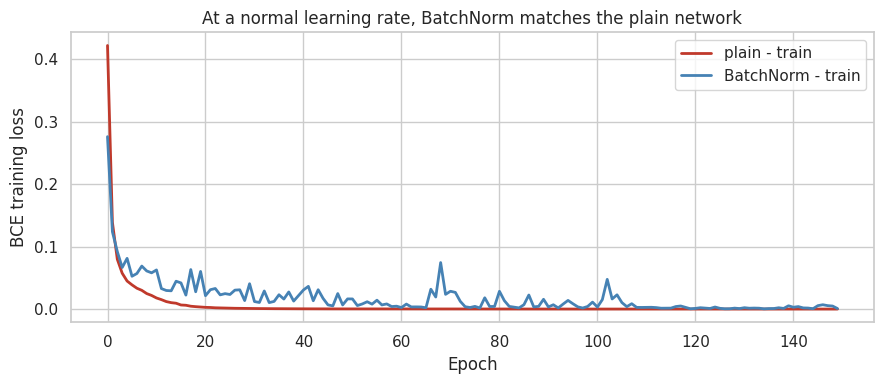

Final training loss   ->  plain: 0.0000   BatchNorm: 0.0009
Best validation loss  ->  plain: 0.0513   BatchNorm: 0.0513

At this learning rate the two are neck and neck: on a problem this easy, with
Adam, BatchNorm neither speeds up nor harms convergence. Its payoff shows up
only when we raise the learning rate - which is what the next experiment does.


In [9]:
class PlainNet(nn.Module):
    """The (256, 256) network from 19_1_2 - no normalization."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


class BNNet(nn.Module):
    """The same (256, 256) network with BatchNorm: Linear -> BN -> ReLU."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)
plain = PlainNet()
plain_train, plain_val = train_and_track(
    plain, torch.optim.Adam(plain.parameters(), lr=1e-3), n_epochs=150
)

torch.manual_seed(42)
bn_model = BNNet()
bn_train, bn_val = train_and_track(
    bn_model, torch.optim.Adam(bn_model.parameters(), lr=1e-3), n_epochs=150
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(plain_train, color='#C0392B',   lw=2, label='plain - train')
ax.plot(bn_train,    color='steelblue', lw=2, label='BatchNorm - train')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE training loss')
ax.set_title('At a normal learning rate, BatchNorm matches the plain network')
ax.legend()
plt.tight_layout()
plt.show()


print(f'Final training loss   ->  plain: {plain_train[-1]:.4f}   BatchNorm: {bn_train[-1]:.4f}')
print(f'Best validation loss  ->  plain: {min(plain_val):.4f}   BatchNorm: {min(bn_val):.4f}')
print()
print('At this learning rate the two are neck and neck: on a problem this easy, with')
print('Adam, BatchNorm neither speeds up nor harms convergence. Its payoff shows up')
print('only when we raise the learning rate - which is what the next experiment does.')

At a normal learning rate the two curves sit almost on top of each other: on a problem this small, with Adam, BatchNorm does not buy you faster convergence. Its real advantage is *stability when the learning rate is large*. A plain network often diverges or thrashes when the learning rate is pushed up; BatchNorm tolerates it. Crank the learning rate up by 50x and compare:

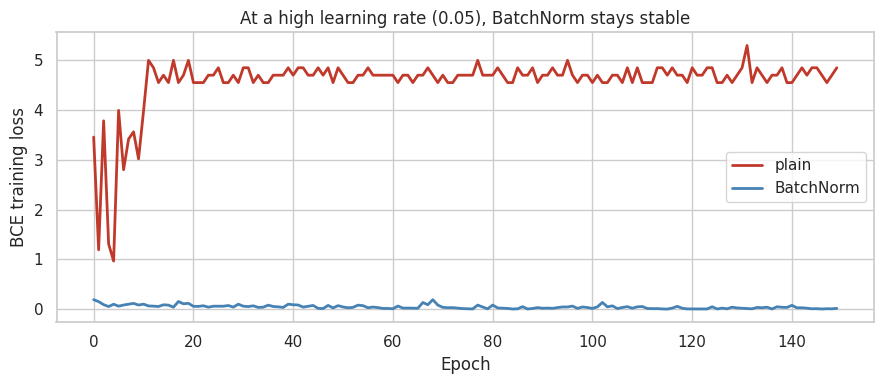

Training loss at epoch 150 (lr = 0.05):
  plain     : 4.8431
  BatchNorm : 0.0176


In [10]:
HIGH_LR = 0.05

torch.manual_seed(42)
plain_hi = PlainNet()
plain_hi_train, _ = train_and_track(
    plain_hi, torch.optim.Adam(plain_hi.parameters(), lr=HIGH_LR), n_epochs=150
)

torch.manual_seed(42)
bn_hi = BNNet()
bn_hi_train, _ = train_and_track(
    bn_hi, torch.optim.Adam(bn_hi.parameters(), lr=HIGH_LR), n_epochs=150
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(plain_hi_train, color='#C0392B',   lw=2, label='plain')
ax.plot(bn_hi_train,    color='steelblue', lw=2, label='BatchNorm')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE training loss')
ax.set_title(f'At a high learning rate ({HIGH_LR}), BatchNorm stays stable')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Training loss at epoch 150 (lr = {HIGH_LR}):')
print(f'  plain     : {plain_hi_train[-1]:.4f}')
print(f'  BatchNorm : {bn_hi_train[-1]:.4f}')

At this aggressive learning rate the plain network's loss is erratic, while the BatchNorm network keeps descending smoothly. By keeping each layer's activations in a sane range, BatchNorm makes the loss surface easier for the optimizer to navigate, so you can take bigger steps without falling apart. This is why almost every modern deep architecture includes some form of normalization.

---

## Section 6: Final Evaluation on the Test Set

To close the loop, we train a BatchNorm model on the combined train+validation data and evaluate once on the untouched **test set**. Note the `model.eval()` call before predicting: now that the network contains BatchNorm layers, skipping it would normalize the test data with batch statistics and keep mutating the running averages — quietly wrong predictions, no error message.

In [11]:
# Combine train + validation for the final fit
X_trainval = torch.cat([X_train, X_val])
y_trainval = torch.cat([y_train, y_val])
trainval_loader = DataLoader(
    TensorDataset(X_trainval, y_trainval), batch_size=BATCH_SIZE, shuffle=True
)

torch.manual_seed(42)
final_model = BNNet()
final_optim = torch.optim.Adam(final_model.parameters(), lr=1e-3)
final_crit  = nn.BCELoss()

for epoch in range(150):
    final_model.train()
    for X_b, y_b in trainval_loader:
        final_optim.zero_grad()
        loss = final_crit(final_model(X_b), y_b)
        loss.backward()
        final_optim.step()

final_model.eval()  # REQUIRED: BatchNorm must use its frozen running stats now
with torch.no_grad():
    test_preds  = (final_model(X_test) > 0.5).long().squeeze().numpy()
    test_labels = y_test.long().squeeze().numpy()

print('Final model: BNNet (256, 256) with BatchNorm')
print()
print(classification_report(test_labels, test_preds, target_names=data.target_names, digits=3))

Final model: BNNet (256, 256) with BatchNorm

              precision    recall  f1-score   support

   malignant      0.953     0.976     0.965        42
      benign      0.986     0.972     0.979        72

    accuracy                          0.974       114
   macro avg      0.970     0.974     0.972       114
weighted avg      0.974     0.974     0.974       114



---

## Putting It All Together

| Concept | What it means |
|---|---|
| Batch normalization | Normalizes each layer's activations to ~0 mean / unit variance within a mini-batch, then applies a learned scale and shift |
| `nn.BatchNorm1d(n)` | The layer for fully connected activations; `n` is the number of features it normalizes |
| Placement | After the linear layer, before the activation: `Linear → BatchNorm → ReLU` |
| Internal covariate shift | The drift in a layer's input distribution as the network trains; BatchNorm tames it |
| Running statistics | `running_mean` / `running_var` — the population estimates accumulated during training |
| `model.train()` | Use batch statistics *and* update the running averages |
| `model.eval()` | Use the frozen running statistics; deterministic, batch-independent predictions |
| Combined block | `Linear → BatchNorm → ReLU → Dropout` — the standard regularized block |
| What BatchNorm buys | Stable training at larger learning rates (plus faster convergence in deep nets / with plain SGD) |

**The habits to lock in:** place BatchNorm as `Linear → BatchNorm → ReLU`, and never predict without `model.eval()` — both dropout and BatchNorm depend on it, for different reasons.

**What is coming next:** Notebook 20_1_3 turns to the **learning rate** itself. BatchNorm lets you use a *larger* learning rate; learning-rate *schedules* let you change it over the course of training — large early to make fast progress, small later to settle into a good minimum.